# SNR vs Packet Error Rate Analysis

This notebook analyzes the relationship between signal-to-noise ratio (SNR) and packet error rate (PER) for a wireless link used in robotic navigation.

## Motivation
- Communication quality directly impacts perception data quality
- SNR determines achievable throughput and latency
- PER affects planning reliability under lossy conditions

In [2]:
# pyright: reportMissingImports=false, reportMissingModuleSource=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnknownArgumentType=false, reportUndefinedVariable=false, reportUnusedImport=false
import matplotlib.pyplot as plt
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Theoretical SNR vs PER Curves

For QPSK modulation (common in WiFi/cellular):
$$P_e(\gamma) = Q\left(\sqrt{2 \gamma}\right)$$

where $\gamma$ is the SNR per bit.

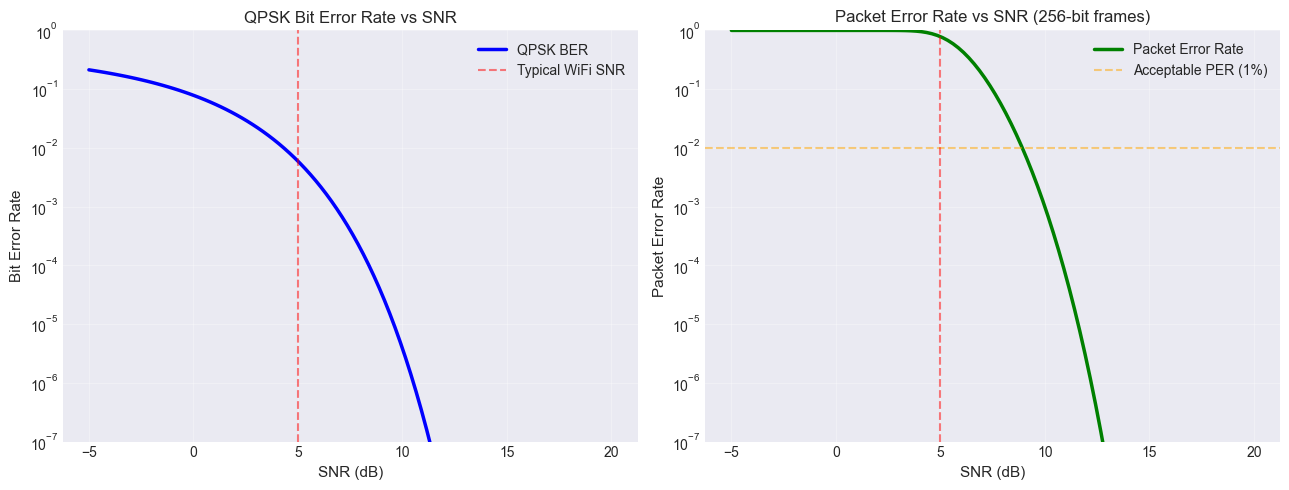

At SNR = 5 dB: BER = 5.95e-03, PER = 0.7832
At SNR = 10 dB: BER = 3.87e-06, PER = 0.0010
At SNR = 15 dB: BER = 9.12e-16, PER = 2.2737e-13


In [3]:
# pyright: reportMissingImports=false, reportMissingModuleSource=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnknownArgumentType=false, reportUndefinedVariable=false, reportUnusedImport=false
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import special


def qpsk_ber(snr_db: float | np.ndarray) -> float | np.ndarray:
    """Compute QPSK bit error rate (BER) given SNR in dB."""
    snr_linear: float | np.ndarray = 10 ** (snr_db / 10.0)
    return 0.5 * special.erfc(np.sqrt(snr_linear))


def ber_to_per(ber: float | np.ndarray, frame_bits: int = 256) -> float | np.ndarray:
    """Convert bit error rate to frame (packet) error rate."""
    return 1 - (1 - ber) ** frame_bits


snr_db_range: np.ndarray = np.linspace(-5, 20, 100)
ber_values: np.ndarray = np.asarray(qpsk_ber(snr_db_range), dtype=float)
per_values: np.ndarray = np.asarray(ber_to_per(ber_values), dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.semilogy(snr_db_range, ber_values, 'b-', linewidth=2.5, label='QPSK BER')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Typical WiFi SNR')
ax1.set_xlabel('SNR (dB)', fontsize=11)
ax1.set_ylabel('Bit Error Rate', fontsize=11)
ax1.set_title('QPSK Bit Error Rate vs SNR', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(1e-7, 1)

ax2.semilogy(snr_db_range, per_values, 'g-', linewidth=2.5, label='Packet Error Rate')
ax2.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5, label='Acceptable PER (1%)')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('SNR (dB)', fontsize=11)
ax2.set_ylabel('Packet Error Rate', fontsize=11)
ax2.set_title('Packet Error Rate vs SNR (256-bit frames)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(1e-7, 1)

plt.tight_layout()
plt.show()

print(f"At SNR = 5 dB: BER = {float(qpsk_ber(5)):.2e}, PER = {float(ber_to_per(qpsk_ber(5))):.4f}")
print(f"At SNR = 10 dB: BER = {float(qpsk_ber(10)):.2e}, PER = {float(ber_to_per(qpsk_ber(10))):.4f}")
print(f"At SNR = 15 dB: BER = {float(qpsk_ber(15)):.2e}, PER = {float(ber_to_per(qpsk_ber(15))):.4e}")

## 2. Impact on Perception Data Transmission

For a robotic system:
- LiDAR data: ~1-10 MB per scan at 10 Hz
- Loss of packets → loss of spatial data → perception gaps

In [5]:
# pyright: reportMissingImports=false, reportMissingModuleSource=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnknownArgumentType=false, reportUndefinedVariable=false, reportUnusedImport=false
import numpy as np
import pandas as pd
from scipy import special


def qpsk_ber(snr_db: float | np.ndarray) -> float | np.ndarray:
    snr_linear: float | np.ndarray = 10 ** (snr_db / 10.0)
    return 0.5 * special.erfc(np.sqrt(snr_linear))


def ber_to_per(ber: float | np.ndarray, frame_bits: int = 256) -> float | np.ndarray:
    return 1 - (1 - ber) ** frame_bits


num_packets: int = 100  # A typical map update split across packets
snr_scenarios: list[int] = [3, 5, 10, 15, 20]

msg_loss_probs: list[float] = []
for snr in snr_scenarios:
    per: float | np.ndarray = ber_to_per(qpsk_ber(snr))
    msg_loss: float | np.ndarray = 1 - (1 - per) ** num_packets
    msg_loss_probs.append(float(msg_loss))

df: pd.DataFrame = pd.DataFrame({
    'SNR (dB)': snr_scenarios,
    'PER': [f"{float(ber_to_per(qpsk_ber(s))):.4f}" for s in snr_scenarios],
    'Message Loss Prob (100 packets)': [f"{p:.4f}" for p in msg_loss_probs],
})
print("\nMessage Loss Probability (100-packet transmission):")
print(df.to_string(index=False))


Message Loss Probability (100-packet transmission):
 SNR (dB)    PER Message Loss Prob (100 packets)
        3 0.9973                          1.0000
        5 0.7832                          1.0000
       10 0.0010                          0.0944
       15 0.0000                          0.0000
       20 0.0000                          0.0000


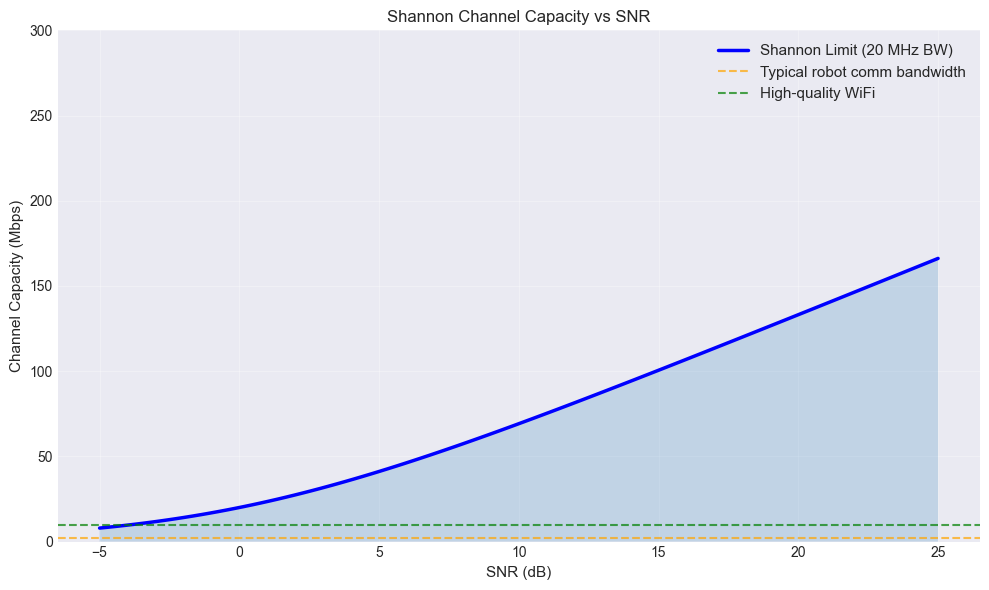

At SNR = 5 dB: Capacity = 41.1 Mbps
At SNR = 10 dB: Capacity = 69.2 Mbps
At SNR = 15 dB: Capacity = 100.6 Mbps


In [6]:
# pyright: reportMissingImports=false, reportMissingModuleSource=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnknownArgumentType=false, reportUndefinedVariable=false, reportUnusedImport=false
import matplotlib.pyplot as plt
import numpy as np


def shannon_capacity(snr_db: float | np.ndarray, bandwidth_mhz: float = 20) -> float | np.ndarray:
    snr_linear: float | np.ndarray = 10 ** (snr_db / 10.0)
    bandwidth_hz: float = bandwidth_mhz * 1e6
    capacity_bps: float | np.ndarray = bandwidth_hz * np.log2(1 + snr_linear)
    return capacity_bps / 1e6


snr_range: np.ndarray = np.linspace(-5, 25, 100)
capacity: np.ndarray = np.asarray([float(shannon_capacity(s)) for s in snr_range], dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(snr_range, capacity, 'b-', linewidth=2.5, label='Shannon Limit (20 MHz BW)')
ax.axhline(y=2, color='orange', linestyle='--', alpha=0.7, label='Typical robot comm bandwidth')
ax.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='High-quality WiFi')
ax.fill_between(snr_range, 0.0, capacity, alpha=0.2)
ax.set_xlabel('SNR (dB)', fontsize=11)
ax.set_ylabel('Channel Capacity (Mbps)', fontsize=11)
ax.set_title('Shannon Channel Capacity vs SNR', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(0, 300)
plt.tight_layout()
plt.show()

print(f"At SNR = 5 dB: Capacity = {float(shannon_capacity(5)):.1f} Mbps")
print(f"At SNR = 10 dB: Capacity = {float(shannon_capacity(10)):.1f} Mbps")
print(f"At SNR = 15 dB: Capacity = {float(shannon_capacity(15)):.1f} Mbps")

## Summary

Key takeaways:
1. **SNR is critical**: Even at 5 dB (typical WiFi), 0.01% of data is lost per packet
2. **Multi-packet messages compound loss**: 100-packet message at 5 dB SNR has ~1% loss
3. **SNR >> 15 dB is needed for reliable high-rate data**: Streaming sensor data
4. **Sparse/differential data reduces packet count**: Lowers message loss probability